In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

np.random.seed(42)

# Project paths
project_root = Path.cwd().parent
dataset_folder = project_root / "Dataset"
raw_folder = dataset_folder / "Raw"
processed_folder = dataset_folder / "Processed"

raw_folder.mkdir(parents=True, exist_ok=True)
processed_folder.mkdir(parents=True, exist_ok=True)

print("Project folders ready.")
print("Raw folder:", raw_folder)
print("Processed folder:", processed_folder)

Project folders ready.
Raw folder: c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Raw
Processed folder: c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Processed


In [2]:
np.random.seed(42)

n_transactions = 200000

transaction_ids = [
    f"TXN{str(i).zfill(8)}"
    for i in range(1, n_transactions + 1)
]

customer_ids = np.random.randint(
    100001,
    130001,
    n_transactions
)

transaction_dates = pd.date_range(
    start="2024-01-01",
    end="2025-12-31",
    periods=n_transactions
)

transaction_types = np.random.choice(
    [
        "Purchase",
        "ATM Withdrawal",
        "Online Transfer",
        "Bank Transfer",
        "Bill Payment"
    ],
    size=n_transactions,
    p=[0.45, 0.15, 0.15, 0.15, 0.10]
)

channels = np.random.choice(
    [
        "POS",
        "Online",
        "Mobile",
        "ATM",
        "Branch"
    ],
    size=n_transactions,
    p=[0.30, 0.30, 0.20, 0.15, 0.05]
)

countries = np.random.choice(
    [
        "UK",
        "India",
        "USA",
        "Germany",
        "France",
        "Singapore",
        "UAE",
        "Australia"
    ],
    size=n_transactions,
    p=[0.35, 0.18, 0.15, 0.08, 0.07, 0.06, 0.06, 0.05]
)

amounts = np.round(
    np.random.lognormal(
        mean=3.8,
        sigma=1.2,
        size=n_transactions
    ),
    2
)

transaction_df = pd.DataFrame({
    "transaction_id": transaction_ids,
    "customer_id": customer_ids,
    "transaction_date": transaction_dates,
    "transaction_type": transaction_types,
    "channel": channels,
    "country": countries,
    "amount": amounts
})

transaction_df.head()

,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount
0,TXN00000001,123655,2024-01-01 00:00:00.000000,Purchase,POS,France,156.11
1,TXN00000002,115796,2024-01-01 00:05:15.361576,Bank Transfer,Mobile,UK,69.84
2,TXN00000003,100861,2024-01-01 00:10:30.723153,Online Transfer,Online,USA,72.78
3,TXN00000004,105391,2024-01-01 00:15:46.084730,ATM Withdrawal,Online,USA,19.85
4,TXN00000005,129803,2024-01-01 00:21:01.446307,Online Transfer,POS,Germany,15.72


In [3]:
transaction_df["is_fraud"] = 0

# Pattern 1 — unusually high transaction amounts
high_amount_threshold = transaction_df["amount"].quantile(0.995)

high_amount_mask = (
    transaction_df["amount"]
    >= high_amount_threshold
)

transaction_df.loc[
    high_amount_mask,
    "is_fraud"
] = np.random.choice(
    [0, 1],
    size=high_amount_mask.sum(),
    p=[0.35, 0.65]
)

# Pattern 2 — suspicious online/mobile international transactions
international_channels = (
    transaction_df["channel"]
    .isin(["Online", "Mobile"])
)

international_countries = (
    transaction_df["country"]
    != "UK"
)

suspicious_mask = (
    international_channels
    & international_countries
)

transaction_df.loc[
    suspicious_mask,
    "is_fraud"
] = np.where(
    np.random.random(
        suspicious_mask.sum()
    ) < 0.08,
    1,
    transaction_df.loc[
        suspicious_mask,
        "is_fraud"
    ]
)

# Pattern 3 — ATM withdrawals with unusually high amounts
atm_mask = (
    (transaction_df["transaction_type"] == "ATM Withdrawal")
    &
    (transaction_df["amount"] > 1000)
)

transaction_df.loc[
    atm_mask,
    "is_fraud"
] = np.where(
    np.random.random(
        atm_mask.sum()
    ) < 0.20,
    1,
    transaction_df.loc[
        atm_mask,
        "is_fraud"
    ]
)

# Save raw dataset
raw_file = (
    raw_folder /
    "financial_transactions_raw.csv"
)

transaction_df.to_csv(
    raw_file,
    index=False
)

print("Dataset created successfully.")
print("Rows:", len(transaction_df))
print("Columns:", len(transaction_df.columns))
print("Fraud transactions:", transaction_df["is_fraud"].sum())
print(
    "Fraud rate:",
    round(
        transaction_df["is_fraud"].mean() * 100,
        2
    ),
    "%"
)

Dataset created successfully.
Rows: 200000
Columns: 8
Fraud transactions: 5831
Fraud rate: 2.92 %


In [4]:
import pandas as pd
import numpy as np

raw_file = (
    raw_folder /
    "financial_transactions_raw.csv"
)

df = pd.read_csv(raw_file)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

Dataset shape: (200000, 8)

Columns:
['transaction_id', 'customer_id', 'transaction_date', 'transaction_type', 'channel', 'country', 'amount', 'is_fraud']

First 5 rows:


,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud
0,TXN00000001,123655,2024-01-01 00:00:00.000000,Purchase,POS,France,156.11,0
1,TXN00000002,115796,2024-01-01 00:05:15.361576,Bank Transfer,Mobile,UK,69.84,0
2,TXN00000003,100861,2024-01-01 00:10:30.723153,Online Transfer,Online,USA,72.78,0
3,TXN00000004,105391,2024-01-01 00:15:46.084730,ATM Withdrawal,Online,USA,19.85,0
4,TXN00000005,129803,2024-01-01 00:21:01.446307,Online Transfer,POS,Germany,15.72,0



Data types:
transaction_id          str
customer_id           int64
transaction_date        str
transaction_type        str
channel                 str
country                 str
amount              float64
is_fraud              int64
dtype: object


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate transaction IDs:")
print(
    df["transaction_id"].duplicated().sum()
)

print("\nDuplicate rows:")
print(
    df.duplicated().sum()
)

Missing values:
transaction_id      0
customer_id         0
transaction_date    0
transaction_type    0
channel             0
country             0
amount              0
is_fraud            0
dtype: int64

Duplicate transaction IDs:
0

Duplicate rows:
0


In [6]:
print("\nAmount statistics:")
print(
    df["amount"].describe()
)


Amount statistics:
count    200000.000000
mean         92.294202
std         167.958164
min           0.200000
25%          19.900000
50%          44.630000
75%         100.412500
max       11639.090000
Name: amount, dtype: float64


In [7]:
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)

df["transaction_year"] = (
    df["transaction_date"].dt.year
)

df["transaction_month"] = (
    df["transaction_date"].dt.month
)

df["transaction_day"] = (
    df["transaction_date"].dt.day
)

df["day_of_week"] = (
    df["transaction_date"].dt.dayofweek
)

df["day_name"] = (
    df["transaction_date"].dt.day_name()
)

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print(
    df[
        [
            "transaction_date",
            "transaction_year",
            "transaction_month",
            "day_of_week",
            "day_name",
            "is_weekend"
        ]
    ].head()
)

            transaction_date  transaction_year  transaction_month  \
0 2024-01-01 00:00:00.000000              2024                  1   
1 2024-01-01 00:05:15.361576              2024                  1   
2 2024-01-01 00:10:30.723153              2024                  1   
3 2024-01-01 00:15:46.084730              2024                  1   
4 2024-01-01 00:21:01.446307              2024                  1   

   day_of_week day_name  is_weekend  
0            0   Monday           0  
1            0   Monday           0  
2            0   Monday           0  
3            0   Monday           0  
4            0   Monday           0  


In [8]:
high_value_threshold = df["amount"].quantile(0.95)

df["is_high_value"] = (
    df["amount"] >= high_value_threshold
).astype(int)

# International transaction indicator
df["is_international"] = (
    df["country"] != "UK"
).astype(int)

# Digital transaction indicator
df["is_digital"] = (
    df["channel"].isin(
        ["Online", "Mobile"]
    )
).astype(int)

# ATM transaction indicator
df["is_atm"] = (
    df["channel"] == "ATM"
).astype(int)

# Log-transformed transaction amount
df["log_amount"] = np.log1p(
    df["amount"]
)

print(
    df[
        [
            "amount",
            "is_high_value",
            "is_international",
            "is_digital",
            "is_atm",
            "log_amount"
        ]
    ].head()
)

   amount  is_high_value  is_international  is_digital  is_atm  log_amount
0  156.11              0                 1           0       0    5.056946
1   69.84              0                 0           1       0    4.260424
2   72.78              0                 1           1       0    4.301088
3   19.85              0                 1           1       0    3.037354
4   15.72              0                 1           0       0    2.816606


In [9]:
fraud_counts = (
    df["is_fraud"]
    .value_counts()
    .sort_index()
)

print("Fraud counts:")
print(fraud_counts)

print("\nFraud percentages:")

fraud_percentage = (
    df["is_fraud"]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

print(fraud_percentage)

Fraud counts:
is_fraud
0    194169
1      5831
Name: count, dtype: int64

Fraud percentages:
is_fraud
0    97.08
1     2.92
Name: proportion, dtype: float64


In [10]:
fraud_summary = (
    df
    .groupby("is_fraud")
    .agg(
        transaction_count=(
            "transaction_id",
            "count"
        ),
        average_amount=(
            "amount",
            "mean"
        ),
        total_amount=(
            "amount",
            "sum"
        ),
        maximum_amount=(
            "amount",
            "max"
        )
    )
    .reset_index()
)

fraud_summary

,is_fraud,transaction_count,average_amount,total_amount,maximum_amount
0,0,194169,87.222976,16935997.99,9037.80
1,1,5831,261.163181,1522842.51,11639.09


In [11]:
channel_fraud = (
    df
    .groupby("channel")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        average_amount=(
            "amount",
            "mean"
        )
    )
    .reset_index()
)

channel_fraud["fraud_rate"] = (
    channel_fraud["fraud_transactions"]
    /
    channel_fraud["transactions"]
    * 100
).round(2)

channel_fraud = channel_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

channel_fraud

,channel,transactions,fraud_transactions,average_amount,fraud_rate
2,Mobile,40145,2223,92.184883,5.54
3,Online,60076,3292,92.459834,5.48
4,POS,60051,198,92.309605,0.33
1,Branch,9858,32,93.021037,0.32
0,ATM,29870,86,91.837158,0.29


In [12]:
country_fraud = (
    df
    .groupby("country")
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        total_transaction_value=(
            "amount",
            "sum"
        ),
        average_transaction_value=(
            "amount",
            "mean"
        )
    )
    .reset_index()
)

country_fraud["fraud_rate"] = (
    country_fraud["fraud_transactions"]
    /
    country_fraud["total_transactions"]
    * 100
).round(2)

country_fraud = country_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

country_fraud

,country,total_transactions,fraud_transactions,total_transaction_value,average_transaction_value,fraud_rate
2,Germany,15993,722,1453418.52,90.878417,4.51
4,Singapore,11831,524,1096740.22,92.700551,4.43
5,UAE,12116,526,1133079.28,93.519254,4.34
1,France,13920,602,1266161.87,90.959904,4.32
7,USA,30075,1283,2801667.61,93.156030,4.27
0,Australia,10135,426,934080.88,92.163876,4.20
3,India,36030,1505,3334493.66,92.547701,4.18
6,UK,69900,243,6439198.46,92.120150,0.35


In [13]:
transaction_type_fraud = (
    df
    .groupby("transaction_type")
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        total_value=(
            "amount",
            "sum"
        ),
        average_amount=(
            "amount",
            "mean"
        )
    )
    .reset_index()
)

transaction_type_fraud["fraud_rate"] = (
    transaction_type_fraud["fraud_transactions"]
    /
    transaction_type_fraud["total_transactions"]
    * 100
).round(2)

transaction_type_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

,transaction_type,total_transactions,fraud_transactions,total_value,average_amount,fraud_rate
0,ATM Withdrawal,29843,897,2747557.74,92.067076,3.01
1,Bank Transfer,29984,877,2772614.85,92.469812,2.92
3,Online Transfer,30041,878,2742588.58,91.294850,2.92
4,Purchase,90057,2605,8303364.45,92.201211,2.89
2,Bill Payment,20075,574,1892714.88,94.282186,2.86


In [14]:
high_value_analysis = (
    df
    .groupby("is_high_value")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        total_value=(
            "amount",
            "sum"
        ),
        average_amount=(
            "amount",
            "mean"
        )
    )
    .reset_index()
)

high_value_analysis["fraud_rate"] = (
    high_value_analysis["fraud_transactions"]
    /
    high_value_analysis["transactions"]
    * 100
).round(2)

high_value_analysis

,is_high_value,transactions,fraud_transactions,total_value,average_amount,fraud_rate
0,0,190000,4917,12360652.83,65.056068,2.59
1,1,10000,914,6098187.67,609.818767,9.14


In [15]:
customer_fraud = (
    df
    .groupby("customer_id")
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),
        total_value=(
            "amount",
            "sum"
        ),
        average_transaction=(
            "amount",
            "mean"
        ),
        maximum_transaction=(
            "amount",
            "max"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        )
    )
    .reset_index()
)

customer_fraud["fraud_rate"] = (
    customer_fraud["fraud_transactions"]
    /
    customer_fraud["total_transactions"]
    * 100
).round(2)

customer_fraud = customer_fraud.sort_values(
    [
        "fraud_transactions",
        "total_value"
    ],
    ascending=False
)

customer_fraud.head(20)

,customer_id,total_transactions,total_value,average_transaction,maximum_transaction,fraud_transactions,fraud_rate
6775,106785,7,773.44,110.491429,386.83,4,57.14
7447,107459,8,744.85,93.106250,238.76,4,50.00
25479,125512,9,3612.35,401.372222,2019.58,3,33.33
20468,120495,7,3197.31,456.758571,2462.58,3,42.86
19092,119117,10,2897.66,289.766000,1270.93,3,30.00
29829,129864,12,2679.19,223.265833,1128.16,3,25.00
17425,117448,7,2455.47,350.781429,1107.62,3,42.86
5409,105414,15,2403.13,160.208667,1780.06,3,20.00
25961,125995,9,2128.35,236.483333,1292.22,3,33.33
4557,104562,13,1931.47,148.574615,1249.61,3,23.08


In [16]:
df["risk_score"] = (
    df["is_high_value"]
    +
    df["is_international"]
    +
    df["is_digital"]
    +
    df["is_atm"]
)

risk_distribution = (
    df["risk_score"]
    .value_counts()
    .sort_index()
)

print("Risk score distribution:")
print(risk_distribution)

Risk score distribution:
risk_score
0    23197
1    87604
2    85010
3     4189
Name: count, dtype: int64


In [17]:
customer_transaction_frequency = (
    df
    .groupby("customer_id")
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),
        total_transaction_value=(
            "amount",
            "sum"
        ),
        average_transaction_value=(
            "amount",
            "mean"
        )
    )
    .reset_index()
)

customer_transaction_frequency.head()

,customer_id,total_transactions,total_transaction_value,average_transaction_value
0,100001,7,454.31,64.901429
1,100002,9,1123.67,124.852222
2,100003,7,475.41,67.915714
3,100004,8,583.42,72.927500
4,100005,6,420.01,70.001667


In [18]:
df = df.sort_values(
    [
        "customer_id",
        "transaction_date"
    ]
).reset_index(drop=True)

In [19]:
# Calculate rolling 24-hour transaction count

df["transaction_count_24h"] = (
    df
    .set_index("transaction_date")
    .groupby("customer_id")["transaction_id"]
    .rolling("24h")
    .count()
    .reset_index(
        level=0,
        drop=True
    )
    .values
)

print(
    df[
        [
            "customer_id",
            "transaction_date",
            "transaction_count_24h"
        ]
    ].head(20)
)

    customer_id           transaction_date  transaction_count_24h
0        100001 2024-06-23 12:52:39.879799                    1.0
1        100001 2024-08-08 14:13:12.255961                    1.0
2        100001 2024-09-01 16:12:27.939739                    1.0
3        100001 2024-11-25 06:15:37.120685                    1.0
4        100001 2025-01-12 04:53:31.432057                    1.0
5        100001 2025-01-28 12:01:40.872504                    1.0
6        100001 2025-11-20 07:41:35.226476                    1.0
7        100002 2024-02-02 10:30:18.333091                    1.0
8        100002 2024-07-13 14:19:47.105935                    1.0
9        100002 2024-07-21 13:38:56.789683                    1.0
10       100002 2024-11-25 13:31:52.131560                    1.0
11       100002 2024-12-14 10:57:03.653118                    1.0
12       100002 2024-12-28 16:25:03.079515                    1.0
13       100002 2025-02-07 03:59:38.327891                    1.0
14       1

In [20]:
df["previous_transaction_date"] = (
    df
    .groupby("customer_id")[
        "transaction_date"
    ]
    .shift(1)
)

df["minutes_since_previous_transaction"] = (
    (
        df["transaction_date"]
        -
        df["previous_transaction_date"]
    )
    .dt.total_seconds()
    / 60
)

df[
    "minutes_since_previous_transaction"
] = df[
    "minutes_since_previous_transaction"
].fillna(999999)

df[
    [
        "customer_id",
        "transaction_date",
        "previous_transaction_date",
        "minutes_since_previous_transaction"
    ]
].head(20)

,customer_id,transaction_date,previous_transaction_date,minutes_since_previous_transaction
0,100001,2024-06-23 12:52:39.879799,NaT,999999.000000
1,100001,2024-08-08 14:13:12.255961,2024-06-23 12:52:39.879799,66320.539603
2,100001,2024-09-01 16:12:27.939739,2024-08-08 14:13:12.255961,34679.261396
3,100001,2024-11-25 06:15:37.120685,2024-09-01 16:12:27.939739,121803.153016
4,100001,2025-01-12 04:53:31.432057,2024-11-25 06:15:37.120685,69037.905190
5,100001,2025-01-28 12:01:40.872504,2025-01-12 04:53:31.432057,23468.157341
6,100001,2025-11-20 07:41:35.226476,2025-01-28 12:01:40.872504,425979.905900
7,100002,2024-02-02 10:30:18.333091,NaT,999999.000000
8,100002,2024-07-13 14:19:47.105935,2024-02-02 10:30:18.333091,233509.479547
9,100002,2024-07-21 13:38:56.789683,2024-07-13 14:19:47.105935,11479.161396


In [21]:
df["is_rapid_transaction"] = (
    df[
        "minutes_since_previous_transaction"
    ] <= 5
).astype(int)

rapid_transaction_summary = (
    df
    .groupby("is_rapid_transaction")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        average_amount=(
            "amount",
            "mean"
        )
    )
    .reset_index()
)

rapid_transaction_summary["fraud_rate"] = (
    rapid_transaction_summary[
        "fraud_transactions"
    ]
    /
    rapid_transaction_summary[
        "transactions"
    ]
    * 100
).round(2)

rapid_transaction_summary

,is_rapid_transaction,transactions,fraud_transactions,average_amount,fraud_rate
0,0,200000,5831,92.294202,2.92


In [22]:
amount_mean = df["amount"].mean()
amount_std = df["amount"].std()

df["amount_z_score"] = (
    df["amount"] - amount_mean
) / amount_std

df["is_amount_anomaly"] = (
    df["amount_z_score"].abs() >= 3
).astype(int)

print(
    "Amount anomalies:",
    df["is_amount_anomaly"].sum()
)

Amount anomalies: 3095


In [23]:
amount_anomaly_analysis = (
    df
    .groupby("is_amount_anomaly")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        average_amount=(
            "amount",
            "mean"
        ),
        maximum_amount=(
            "amount",
            "max"
        )
    )
    .reset_index()
)

amount_anomaly_analysis["fraud_rate"] = (
    amount_anomaly_analysis[
        "fraud_transactions"
    ]
    /
    amount_anomaly_analysis[
        "transactions"
    ]
    * 100
).round(2)

amount_anomaly_analysis

,is_amount_anomaly,transactions,fraud_transactions,average_amount,maximum_amount,fraud_rate
0,0,196905,5114,77.720405,596.13,2.60
1,1,3095,717,1019.484407,11639.09,23.17


In [24]:
df["behavioural_risk_score"] = (
    df["is_high_value"]
    +
    df["is_international"]
    +
    df["is_digital"]
    +
    df["is_rapid_transaction"]
    +
    df["is_amount_anomaly"]
)

behavioural_risk_analysis = (
    df
    .groupby("behavioural_risk_score")
    .agg(
        transactions=(
            "transaction_id",
            "count"
        ),
        fraud_transactions=(
            "is_fraud",
            "sum"
        ),
        average_amount=(
            "amount",
            "mean"
        ),
        total_transaction_value=(
            "amount",
            "sum"
        )
    )
    .reset_index()
)

behavioural_risk_analysis["fraud_rate"] = (
    behavioural_risk_analysis[
        "fraud_transactions"
    ]
    /
    behavioural_risk_analysis[
        "transactions"
    ]
    * 100
).round(2)

behavioural_risk_analysis

,behavioural_risk_score,transactions,fraud_transactions,average_amount,total_transaction_value,fraud_rate
0,0,33179,0,64.780845,2149363.65,0.00
1,1,95998,0,69.663969,6687601.69,0.00
2,2,66039,5028,91.629834,6051142.62,7.61
3,3,3796,534,670.259233,2544304.05,14.07
4,4,988,269,1038.895233,1026428.49,27.23


In [25]:
processed_file = (
    processed_folder /
    "financial_transactions_processed.csv"
)

df.to_csv(
    processed_file,
    index=False
)

print("Processed dataset exported successfully.")
print(processed_file)

Processed dataset exported successfully.
c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Processed\financial_transactions_processed.csv


In [26]:
print(
    processed_file.exists()
)

True


In [27]:
df["previous_transaction_date"] = pd.to_datetime(
    df["previous_transaction_date"],
    errors="coerce"
)

print(
    "Missing previous transaction dates:",
    df["previous_transaction_date"].isna().sum()
)

Missing previous transaction dates: 29966


In [28]:
processed_file = (
    processed_folder /
    "financial_transactions_processed.csv"
)

df.to_csv(
    processed_file,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

print("Corrected dataset exported successfully.")
print(processed_file)

Corrected dataset exported successfully.
c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Processed\financial_transactions_processed.csv


In [29]:
df["previous_transaction_date"] = pd.to_datetime(
    df["previous_transaction_date"],
    errors="coerce"
)

# Create a copy specifically for MySQL import
mysql_df = df.copy()

# Convert missing datetime values to MySQL NULL representation
mysql_df["previous_transaction_date"] = (
    mysql_df["previous_transaction_date"]
    .dt.strftime("%Y-%m-%d %H:%M:%S")
)

mysql_df["previous_transaction_date"] = (
    mysql_df["previous_transaction_date"]
    .fillna("\\N")
)

mysql_df.to_csv(
    processed_folder / "financial_transactions_mysql.csv",
    index=False,
    na_rep="\\N"
)

print("MySQL-ready CSV created successfully.")

MySQL-ready CSV created successfully.


In [30]:
mysql_file = (
    processed_folder /
    "financial_transactions_mysql.csv"
)

check_df = pd.read_csv(
    mysql_file,
    na_values="\\N"
)

print(check_df["previous_transaction_date"].isna().sum())

print(check_df.shape)

print(
    check_df[
        "previous_transaction_date"
    ].head(10)
)

29966
(200000, 27)
0                    NaN
1    2024-06-23 12:52:39
2    2024-08-08 14:13:12
3    2024-09-01 16:12:27
4    2024-11-25 06:15:37
5    2025-01-12 04:53:31
6    2025-01-28 12:01:40
7                    NaN
8    2024-02-02 10:30:18
9    2024-07-13 14:19:47
Name: previous_transaction_date, dtype: str


In [31]:
with open(
    mysql_file,
    "r",
    encoding="utf-8"
) as f:
    for _ in range(5):
        print(f.readline().strip())

transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud,transaction_year,transaction_month,transaction_day,day_of_week,day_name,is_weekend,is_high_value,is_international,is_digital,is_atm,log_amount,risk_score,transaction_count_24h,previous_transaction_date,minutes_since_previous_transaction,is_rapid_transaction,amount_z_score,is_amount_anomaly,behavioural_risk_score
TXN00047819,100001,2024-06-23 12:52:39.879799,Purchase,ATM,India,88.37,0,2024,6,23,6,Sunday,1,0,1,0,1,4.492785055393301,2,1.0,\N,999999.0,0,-0.023364166405707792,0,1
TXN00060437,100001,2024-08-08 14:13:12.255961,Online Transfer,POS,India,13.27,0,2024,8,8,3,Thursday,0,0,1,0,0,2.658159431488745,1,1.0,2024-06-23 12:52:39,66320.5396027,0,-0.4704993224198683,0,1
TXN00067035,100001,2024-09-01 16:12:27.939739,ATM Withdrawal,Online,Singapore,96.19,0,2024,9,1,6,Sunday,1,0,1,1,0,4.576667825515379,2,1.0,2024-08-08 14:13:12,34679.261396300004,0,0.023195046910280646,0,2
TXN00090209,100001,2024-11-25

In [32]:
print(check_df["previous_transaction_date"].isna().sum())

29966


In [33]:
customer_ml_file = (processed_folder / "customer_ml_features.csv")
customer_ml = pd.read_csv(customer_ml_file)
print("Customer ML dataset shape:",customer_ml.shape)
display(customer_ml.head())

Customer ML dataset shape: (1000, 16)


,customer_id,total_transactions,active_days,total_transaction_value,average_transaction_amount,maximum_transaction_amount,historical_fraud_transactions,historical_fraud_rate,average_transaction_velocity,maximum_transaction_velocity,rapid_transaction_count,amount_anomaly_count,international_transaction_count,digital_transaction_count,average_behavioural_risk_score,maximum_behavioural_risk_score
0,100001,7,7,454.31,64.901429,169.00,0,0.0,1.0,1.0,0,0,5,4,1.2857,2
1,100002,9,9,1123.67,124.852222,678.06,0,0.0,1.0,1.0,0,1,6,4,1.3333,3
2,100003,7,7,475.41,67.915714,291.14,0,0.0,1.0,1.0,0,0,4,3,1.0000,2
3,100004,8,8,583.42,72.927500,482.00,0,0.0,1.0,1.0,0,0,6,3,1.2500,2
4,100005,6,6,420.01,70.001667,90.26,0,0.0,1.0,1.0,0,0,3,3,1.0000,2


In [34]:
print(
    customer_ml.columns.tolist()
)

['customer_id', 'total_transactions', 'active_days', 'total_transaction_value', 'average_transaction_amount', 'maximum_transaction_amount', 'historical_fraud_transactions', 'historical_fraud_rate', 'average_transaction_velocity', 'maximum_transaction_velocity', 'rapid_transaction_count', 'amount_anomaly_count', 'international_transaction_count', 'digital_transaction_count', 'average_behavioural_risk_score', 'maximum_behavioural_risk_score']


In [35]:
customer_ml["fraud_target"] = np.where(customer_ml["historical_fraud_transactions"] > 0, 1, 0)
print("Target distribution:")
print(customer_ml["fraud_target"].value_counts())
print("\nTarget percentage:")
print(customer_ml["fraud_target"].value_counts(normalize=True).mul(100).round(2))

Target distribution:
fraud_target
0    813
1    187
Name: count, dtype: int64

Target percentage:
fraud_target
0    81.3
1    18.7
Name: proportion, dtype: float64


In [36]:
fraud_features = [
    "total_transactions",
    "total_transaction_value",
    "average_transaction_amount",
    "maximum_transaction_amount",
    "average_transaction_velocity",
    "maximum_transaction_velocity",
    "rapid_transaction_count",
    "amount_anomaly_count",
    "international_transaction_count",
    "digital_transaction_count",
    "average_behavioural_risk_score",
    "maximum_behavioural_risk_score"
]
X_fraud = customer_ml[fraud_features].copy()
y_fraud = customer_ml["fraud_target"].copy()
print("Feature matrix shape:", X_fraud.shape)
print("Target vector shape:", y_fraud.shape)
print("\nSelected features:")
print(fraud_features)

Feature matrix shape: (1000, 12)
Target vector shape: (1000,)

Selected features:
['total_transactions', 'total_transaction_value', 'average_transaction_amount', 'maximum_transaction_amount', 'average_transaction_velocity', 'maximum_transaction_velocity', 'rapid_transaction_count', 'amount_anomaly_count', 'international_transaction_count', 'digital_transaction_count', 'average_behavioural_risk_score', 'maximum_behavioural_risk_score']


In [37]:
class_counts = (y_fraud.value_counts().sort_index())
class_percentages = (y_fraud.value_counts(normalize=True).sort_index().mul(100).round(2))
imbalance_summary = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "percentage": class_percentages.values})
display(imbalance_summary)

,class,count,percentage
0,0,813,81.3
1,1,187,18.7


In [38]:
class_0_count = ((y_fraud == 0).sum())
class_1_count = ((y_fraud == 1).sum())
imbalance_ratio = (class_0_count /class_1_count)
print("Class imbalance ratio:", round(imbalance_ratio, 2))

Class imbalance ratio: 4.35


In [39]:
from sklearn.model_selection import train_test_split

X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = (
    train_test_split(
        X_fraud,
        y_fraud,
        test_size=0.20,
        random_state=42,
        stratify=y_fraud))
print("Training records:", len(X_train_fraud))
print("Testing records:", len(X_test_fraud))
print("\nTraining fraud rate:", round(y_train_fraud.mean() * 100, 2),"%")
print("Testing fraud rate:", round(y_test_fraud.mean() * 100,2),"%")

Training records: 800
Testing records: 200

Training fraud rate: 18.75 %
Testing fraud rate: 18.5 %


In [40]:
stratify=y_fraud

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
logistic_fraud_model = Pipeline([("scaler",StandardScaler()),
    ("model",LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42))])
logistic_fraud_model.fit(X_train_fraud,y_train_fraud)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [42]:
from sklearn.ensemble import RandomForestClassifier
rf_fraud_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)
rf_fraud_model.fit(X_train_fraud,y_train_fraud)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [44]:
from imblearn.ensemble import BalancedRandomForestClassifier
balanced_rf_model = BalancedRandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1)
balanced_rf_model.fit(X_train_fraud,y_train_fraud)

print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


In [45]:
logistic_predictions = (logistic_fraud_model.predict(X_test_fraud))

logistic_probabilities = (logistic_fraud_model.predict_proba(X_test_fraud)[:, 1])

rf_predictions = (rf_fraud_model.predict(X_test_fraud))

rf_probabilities = (rf_fraud_model.predict_proba(X_test_fraud)[:, 1])

balanced_rf_predictions = (balanced_rf_model.predict(X_test_fraud))

balanced_rf_probabilities = (balanced_rf_model.predict_proba(X_test_fraud)[:, 1])

print("Predictions generated successfully.")

Predictions generated successfully.


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score)

model_results = []
models = {"Logistic Regression": (logistic_predictions,logistic_probabilities),"Random Forest": (
        rf_predictions,
        rf_probabilities),

    "Balanced Random Forest": (
        balanced_rf_predictions,
        balanced_rf_probabilities
    )}

for model_name, (predictions,probabilities) in models.items():

    model_results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test_fraud,
            predictions
        ),

        "Precision": precision_score(
            y_test_fraud,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test_fraud,
            predictions,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_test_fraud,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test_fraud,
            probabilities
        )
    })

model_comparison = pd.DataFrame(
    model_results
).round(4)

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.715,0.3485,0.6216,0.4466,0.7233
1,Random Forest,0.750,0.3860,0.5946,0.4681,0.7415
2,Balanced Random Forest,0.740,0.3810,0.6486,0.4800,0.7266


In [47]:
feature_importance = pd.DataFrame({"feature": X_fraud.columns,"importance": rf_fraud_model.feature_importances_})

feature_importance = (feature_importance.sort_values("importance",ascending=False).reset_index(drop=True))

feature_importance["importance"] = (feature_importance["importance"].round(4))

display(feature_importance)

,feature,importance
0,average_behavioural_risk_score,0.2099
1,maximum_transaction_amount,0.1662
2,total_transaction_value,0.1592
3,average_transaction_amount,0.1391
4,digital_transaction_count,0.1002
5,international_transaction_count,0.0908
6,total_transactions,0.0733
7,maximum_behavioural_risk_score,0.0386
8,average_transaction_velocity,0.0100
9,maximum_transaction_velocity,0.0071


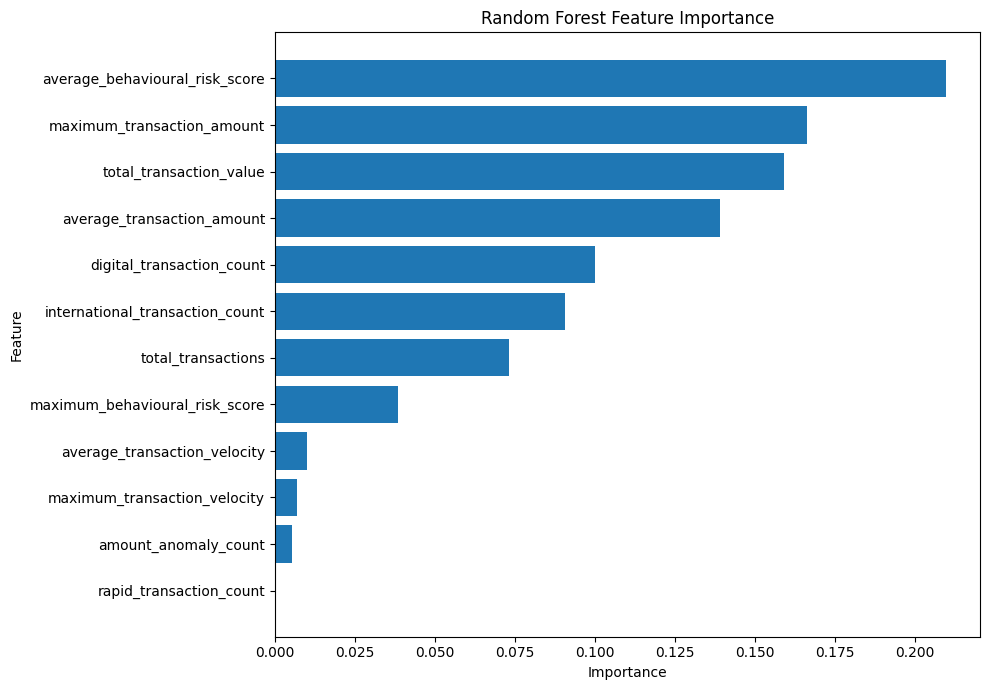

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))

plt.barh(feature_importance["feature"],feature_importance["importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

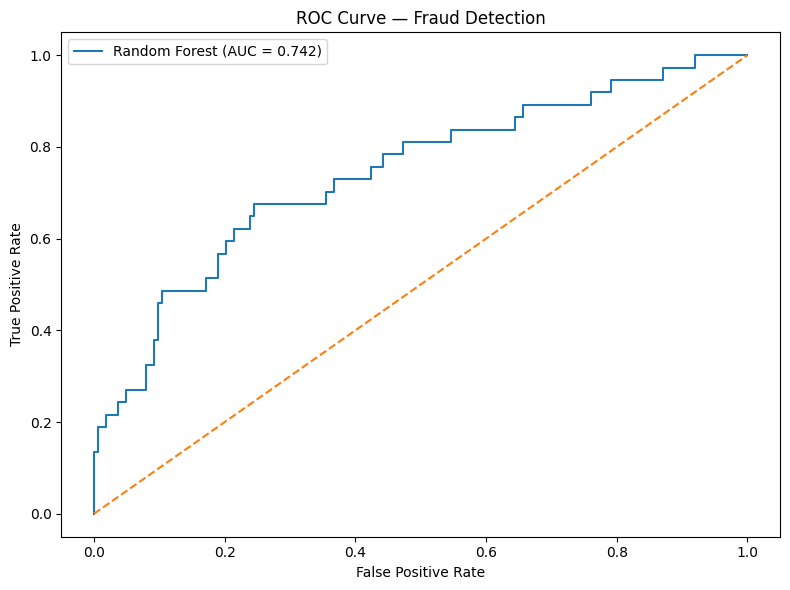

In [49]:
from sklearn.metrics import (roc_curve,auc)

fpr, tpr, thresholds = roc_curve(y_test_fraud,rf_probabilities)

roc_auc_value = auc(fpr,tpr)

plt.figure(figsize=(8, 6))

plt.plot(fpr,tpr,label=f"Random Forest (AUC = {roc_auc_value:.3f})")

plt.plot([0, 1],[0, 1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Fraud Detection")

plt.legend()

plt.tight_layout()
plt.show()

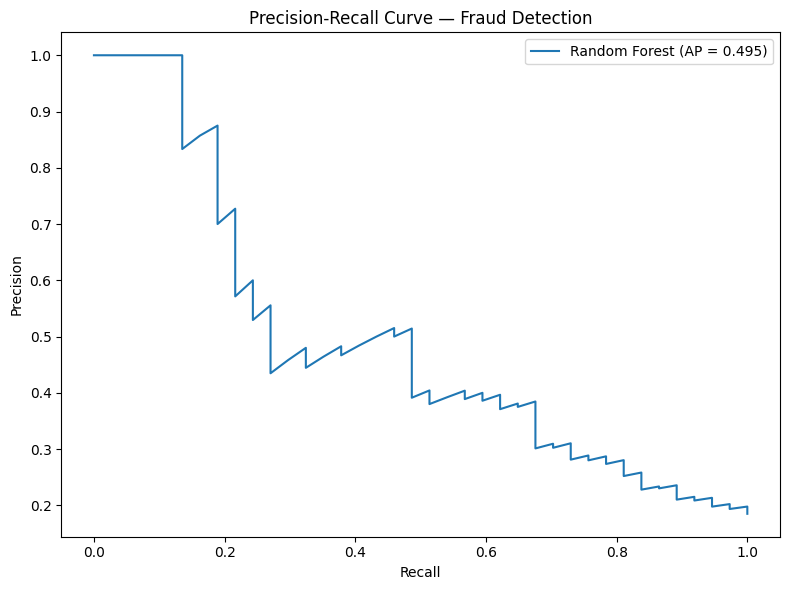

In [50]:
from sklearn.metrics import (precision_recall_curve,average_precision_score)

precision_values, recall_values, pr_thresholds = (precision_recall_curve(y_test_fraud,rf_probabilities))

average_precision = (average_precision_score(y_test_fraud,rf_probabilities))

plt.figure(figsize=(8, 6))

plt.plot(recall_values,precision_values,label=f"Random Forest (AP = {average_precision:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve — Fraud Detection")

plt.legend()

plt.tight_layout()
plt.show()

In [51]:
threshold_results = []

for threshold in np.arange(0.10,0.91,0.05):

    threshold_predictions = (rf_probabilities >= threshold).astype(int)

    threshold_precision = precision_score(y_test_fraud,threshold_predictions,zero_division=0)

    threshold_recall = recall_score(y_test_fraud,threshold_predictions,zero_division=0)

    threshold_f1 = f1_score(y_test_fraud,threshold_predictions,zero_division=0)

    threshold_results.append({"threshold": round(threshold,2),
        "precision": threshold_precision,
        "recall": threshold_recall,
        "f1_score": threshold_f1})

threshold_analysis = pd.DataFrame(threshold_results).round(4)

display(threshold_analysis)

,threshold,precision,recall,f1_score
0,0.10,0.2011,0.9730,0.3333
1,0.15,0.2134,0.9459,0.3483
2,0.20,0.2215,0.8919,0.3548
3,0.25,0.2279,0.8378,0.3584
4,0.30,0.2480,0.8378,0.3827
5,0.35,0.2736,0.7838,0.4056
6,0.40,0.3103,0.7297,0.4355
7,0.45,0.3472,0.6757,0.4587
8,0.50,0.3860,0.5946,0.4681
9,0.55,0.4000,0.4865,0.4390


In [52]:
best_threshold_row = (threshold_analysis.loc[threshold_analysis["f1_score"].idxmax()])

print("Best threshold by F1 score:",best_threshold_row["threshold"])

print("Precision:",best_threshold_row["precision"])

print("Recall:",best_threshold_row["recall"])

print("F1 Score:",best_threshold_row["f1_score"])

Best threshold by F1 score: 0.5
Precision: 0.386
Recall: 0.5946
F1 Score: 0.4681


In [53]:
transaction_features = [
    "amount",
    "is_high_value",
    "is_international",
    "is_digital",
    "is_atm",
    "transaction_count_24h",
    "minutes_since_previous_transaction",
    "is_rapid_transaction",
    "amount_z_score",
    "is_amount_anomaly",
    "risk_score",
    "behavioural_risk_score",
    "is_weekend"]
X_transaction = df[transaction_features].copy()
y_transaction = df["is_fraud"].copy()
print("Transaction feature matrix:",X_transaction.shape)
print("Transaction target:",y_transaction.shape)

Transaction feature matrix: (200000, 13)
Transaction target: (200000,)


In [54]:
X_train_txn, X_test_txn, y_train_txn, y_test_txn = (
    train_test_split(
        X_transaction,
        y_transaction,
        test_size=0.20,
        random_state=42,
        stratify=y_transaction))

transaction_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1)

transaction_rf_model.fit(X_train_txn,y_train_txn)

print("Transaction-level Random Forest trained successfully.")

Transaction-level Random Forest trained successfully.


In [55]:
transaction_fraud_probability = (transaction_rf_model.predict_proba(X_transaction)[:, 1])

transaction_fraud_prediction = (transaction_rf_model.predict(X_transaction))

transaction_predictions = df[[
        "transaction_id",
        "customer_id",
        "transaction_date",
        "transaction_type",
        "channel",
        "country",
        "amount",
        "is_fraud"
    ]].copy()

transaction_predictions["fraud_probability"] = transaction_fraud_probability

transaction_predictions["model_prediction"] = transaction_fraud_prediction

display(transaction_predictions.head(10))

,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud,fraud_probability,model_prediction
0,TXN00047819,100001,2024-06-23 12:52:39.879799,Purchase,ATM,India,88.37,0,0.000000,0
1,TXN00060437,100001,2024-08-08 14:13:12.255961,Online Transfer,POS,India,13.27,0,0.000000,0
2,TXN00067035,100001,2024-09-01 16:12:27.939739,ATM Withdrawal,Online,Singapore,96.19,0,0.742347,1
3,TXN00090209,100001,2024-11-25 06:15:37.120685,Purchase,Online,UK,15.80,0,0.000000,0
4,TXN00103344,100001,2025-01-12 04:53:31.432057,Bank Transfer,ATM,Germany,169.00,0,0.000000,0
5,TXN00107809,100001,2025-01-28 12:01:40.872504,ATM Withdrawal,Mobile,UK,58.37,0,0.000000,0
6,TXN00188855,100001,2025-11-20 07:41:35.226476,Bill Payment,Mobile,UAE,13.31,0,0.708256,1
7,TXN00008888,100002,2024-02-02 10:30:18.333091,ATM Withdrawal,Online,UK,53.28,0,0.000000,0
8,TXN00053315,100002,2024-07-13 14:19:47.105935,Purchase,POS,UK,12.80,0,0.000000,0
9,TXN00055499,100002,2024-07-21 13:38:56.789683,Bill Payment,ATM,UK,6.20,0,0.000000,0


In [56]:
transaction_predictions["risk_category"] = pd.cut(
    transaction_predictions[
        "fraud_probability"
    ],
    bins=[
        -0.01,
        0.25,
        0.50,
        0.75,
        1.00
    ],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Critical Risk"])

print(transaction_predictions["risk_category"].value_counts())

risk_category
Low Risk         134114
High Risk         55975
Critical Risk      9408
Medium Risk         503
Name: count, dtype: int64


In [57]:
high_risk_transactions = (
    transaction_predictions[
        transaction_predictions[
            "risk_category"
        ].isin(["High Risk","Critical Risk"])].sort_values(
        ["fraud_probability","amount"],ascending=False))

print("High/Critical risk transactions:",len(high_risk_transactions))

display(high_risk_transactions.head(25))

High/Critical risk transactions: 65383


,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud,fraud_probability,model_prediction,risk_category
193545,TXN00006496,129032,2024-01-24 16:57:53.441367,Purchase,Mobile,India,1309.81,1,0.995699,1,Critical Risk
149637,TXN00116885,122477,2025-03-02 15:05:22.543612,ATM Withdrawal,POS,UK,3160.45,1,0.995544,1,Critical Risk
185151,TXN00153462,127772,2025-07-14 03:15:02.938514,Purchase,Online,Germany,2893.00,1,0.995287,1,Critical Risk
172211,TXN00184468,125836,2025-11-04 07:23:23.989019,Purchase,Online,UAE,2204.77,1,0.995140,1,Critical Risk
17582,TXN00138561,102666,2025-05-20 17:55:00.082500,Purchase,Mobile,Singapore,1277.93,1,0.995094,1,Critical Risk
63834,TXN00116236,109633,2025-02-28 06:14:12.880264,Bank Transfer,Online,Singapore,1313.38,1,0.994919,1,Critical Risk
11207,TXN00088181,101711,2024-11-17 20:36:23.842919,Purchase,Online,UK,1104.29,1,0.994782,1,Critical Risk
181685,TXN00064262,127255,2024-08-22 13:17:30.287251,Bill Payment,Online,France,1380.01,1,0.994687,1,Critical Risk
19137,TXN00119098,102896,2025-03-10 16:56:57.713088,Purchase,Mobile,UAE,2205.83,1,0.994665,1,Critical Risk
120220,TXN00109849,118075,2025-02-04 22:43:58.489192,Bank Transfer,Online,USA,1153.91,1,0.994640,1,Critical Risk


In [58]:
high_value_risk_transactions = (
    transaction_predictions[
        (
            transaction_predictions[
                "risk_category"
            ].isin(["High Risk","Critical Risk"]))&(transaction_predictions["amount"]>= transaction_predictions["amount"].quantile(0.95))]
    .sort_values("amount",ascending=False))

display(high_value_risk_transactions.head(25))

,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud,fraud_probability,model_prediction,risk_category
40052,TXN00168606,106037,2025-09-07 09:52:18.657693,Purchase,Mobile,Australia,11639.09,1,0.972050,1,Critical Risk
105497,TXN00080534,115884,2024-10-20 22:43:33.865069,Bill Payment,Mobile,UK,9037.80,0,0.973860,1,Critical Risk
93043,TXN00032764,114008,2024-04-29 14:03:11.340956,Bill Payment,POS,India,8544.17,0,0.967101,1,Critical Risk
185959,TXN00180912,127889,2025-10-22 07:52:58.221891,Purchase,Mobile,USA,6844.37,0,0.970724,1,Critical Risk
44103,TXN00009949,106655,2024-02-06 07:26:56.966084,ATM Withdrawal,Online,UK,6280.76,1,0.978897,1,Critical Risk
127302,TXN00028769,119132,2024-04-15 00:05:21.841609,Bank Transfer,Online,Australia,6158.73,1,0.972863,1,Critical Risk
152585,TXN00026937,122917,2024-04-08 07:36:19.432897,Purchase,Online,Germany,5948.55,0,0.967675,1,Critical Risk
19094,TXN00059300,102888,2024-08-04 10:37:06.143130,Bill Payment,Mobile,USA,5695.04,0,0.968610,1,Critical Risk
170569,TXN00158313,125581,2025-07-31 20:12:01.947609,Purchase,Mobile,India,5312.50,1,0.985477,1,Critical Risk
17671,TXN00070345,102678,2024-09-13 18:09:54.758973,Bank Transfer,Online,India,4777.16,0,0.987739,1,Critical Risk


In [59]:
transaction_feature_importance = pd.DataFrame({
    "feature": transaction_features,
    "importance": transaction_rf_model.feature_importances_})

transaction_feature_importance = (transaction_feature_importance.sort_values("importance",ascending=False).reset_index(drop=True))

transaction_feature_importance["importance"] = (transaction_feature_importance["importance"].round(4))

display(transaction_feature_importance)

,feature,importance
0,behavioural_risk_score,0.3618
1,risk_score,0.2489
2,is_digital,0.1430
3,is_international,0.0802
4,amount,0.0504
5,amount_z_score,0.0450
6,is_atm,0.0362
7,is_amount_anomaly,0.0183
8,is_high_value,0.0084
9,minutes_since_previous_transaction,0.0072


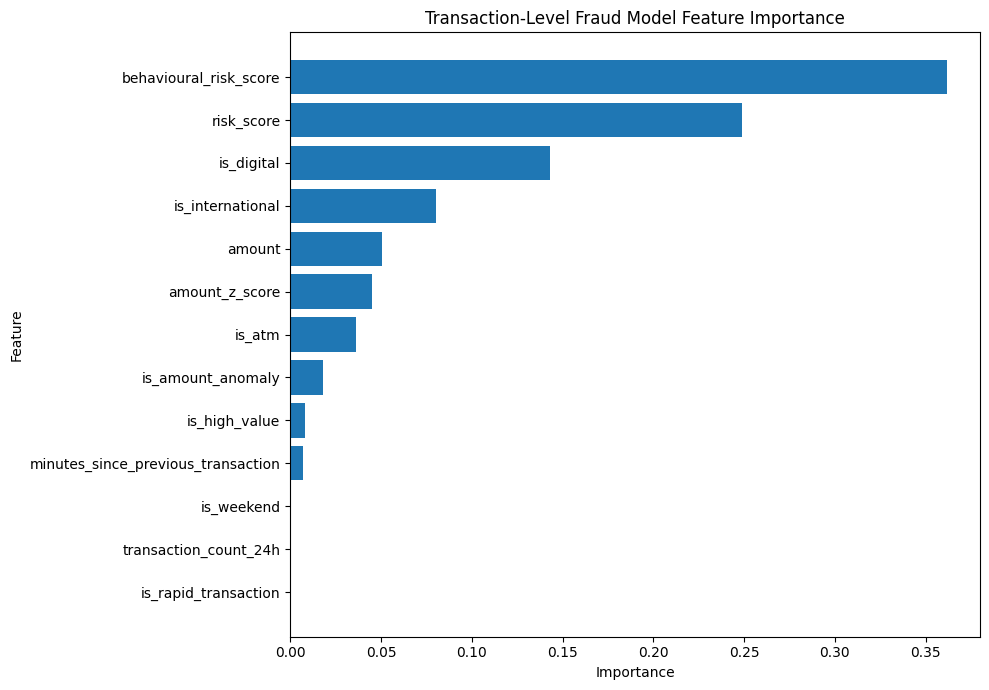

In [60]:
plt.figure(figsize=(10, 7))

plt.barh(transaction_feature_importance["feature"],transaction_feature_importance["importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Transaction-Level Fraud Model Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [61]:
transaction_test_predictions = (transaction_rf_model.predict(X_test_txn))

transaction_test_probabilities = (transaction_rf_model.predict_proba(X_test_txn)[:, 1])

transaction_accuracy = accuracy_score(y_test_txn,transaction_test_predictions)

transaction_precision = precision_score(y_test_txn,transaction_test_predictions,zero_division=0)

transaction_recall = recall_score(y_test_txn,transaction_test_predictions,zero_division=0)

transaction_f1 = f1_score(y_test_txn,transaction_test_predictions,zero_division=0)

transaction_roc_auc = roc_auc_score(y_test_txn,transaction_test_probabilities)

print("Transaction-Level Random Forest")
print("=" * 45)
print(f"Accuracy : {transaction_accuracy:.4f}")
print(f"Precision: {transaction_precision:.4f}")
print(f"Recall   : {transaction_recall:.4f}")
print(f"F1 Score : {transaction_f1:.4f}")
print(f"ROC-AUC  : {transaction_roc_auc:.4f}")

Transaction-Level Random Forest
Accuracy : 0.7011
Precision: 0.0885
Recall   : 0.9949
F1 Score : 0.1625
ROC-AUC  : 0.8639


In [62]:
from sklearn.metrics import (confusion_matrix,classification_report)
print("\nConfusion Matrix:")

print(confusion_matrix(y_test_txn,transaction_test_predictions))

print("\nClassification Report:")

print(classification_report(y_test_txn,transaction_test_predictions,zero_division=0))


Confusion Matrix:
[[26883 11951]
 [    6  1160]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.69      0.82     38834
           1       0.09      0.99      0.16      1166

    accuracy                           0.70     40000
   macro avg       0.54      0.84      0.49     40000
weighted avg       0.97      0.70      0.80     40000



In [63]:
fraud_monitoring = transaction_predictions.copy()

fraud_monitoring["transaction_year"] = (pd.to_datetime(fraud_monitoring["transaction_date"]).dt.year)

fraud_monitoring["transaction_month"] = (pd.to_datetime(fraud_monitoring["transaction_date"]).dt.month)

fraud_monitoring["transaction_day"] = (pd.to_datetime(fraud_monitoring["transaction_date"]).dt.day)

fraud_monitoring["is_actual_fraud"] = (fraud_monitoring["is_fraud"])

fraud_monitoring["correct_prediction"] = (fraud_monitoring["model_prediction"]==fraud_monitoring["is_fraud"]).astype(int)

fraud_monitoring.head()

,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud,fraud_probability,model_prediction,risk_category,transaction_year,transaction_month,transaction_day,is_actual_fraud,correct_prediction
0,TXN00047819,100001,2024-06-23 12:52:39.879799,Purchase,ATM,India,88.37,0,0.000000,0,Low Risk,2024,6,23,0,1
1,TXN00060437,100001,2024-08-08 14:13:12.255961,Online Transfer,POS,India,13.27,0,0.000000,0,Low Risk,2024,8,8,0,1
2,TXN00067035,100001,2024-09-01 16:12:27.939739,ATM Withdrawal,Online,Singapore,96.19,0,0.742347,1,High Risk,2024,9,1,0,0
3,TXN00090209,100001,2024-11-25 06:15:37.120685,Purchase,Online,UK,15.80,0,0.000000,0,Low Risk,2024,11,25,0,1
4,TXN00103344,100001,2025-01-12 04:53:31.432057,Bank Transfer,ATM,Germany,169.00,0,0.000000,0,Low Risk,2025,1,12,0,1


In [64]:
fraud_monitoring["potential_exposure"] = np.where(
    fraud_monitoring["risk_category"].isin(["High Risk","Critical Risk"]),fraud_monitoring["amount"],0)

print("Fraud monitoring dataset created.")

display(fraud_monitoring.head(10))

Fraud monitoring dataset created.


,transaction_id,customer_id,transaction_date,transaction_type,channel,country,amount,is_fraud,fraud_probability,model_prediction,risk_category,transaction_year,transaction_month,transaction_day,is_actual_fraud,correct_prediction,potential_exposure
0,TXN00047819,100001,2024-06-23 12:52:39.879799,Purchase,ATM,India,88.37,0,0.000000,0,Low Risk,2024,6,23,0,1,0.00
1,TXN00060437,100001,2024-08-08 14:13:12.255961,Online Transfer,POS,India,13.27,0,0.000000,0,Low Risk,2024,8,8,0,1,0.00
2,TXN00067035,100001,2024-09-01 16:12:27.939739,ATM Withdrawal,Online,Singapore,96.19,0,0.742347,1,High Risk,2024,9,1,0,0,96.19
3,TXN00090209,100001,2024-11-25 06:15:37.120685,Purchase,Online,UK,15.80,0,0.000000,0,Low Risk,2024,11,25,0,1,0.00
4,TXN00103344,100001,2025-01-12 04:53:31.432057,Bank Transfer,ATM,Germany,169.00,0,0.000000,0,Low Risk,2025,1,12,0,1,0.00
5,TXN00107809,100001,2025-01-28 12:01:40.872504,ATM Withdrawal,Mobile,UK,58.37,0,0.000000,0,Low Risk,2025,1,28,0,1,0.00
6,TXN00188855,100001,2025-11-20 07:41:35.226476,Bill Payment,Mobile,UAE,13.31,0,0.708256,1,High Risk,2025,11,20,0,0,13.31
7,TXN00008888,100002,2024-02-02 10:30:18.333091,ATM Withdrawal,Online,UK,53.28,0,0.000000,0,Low Risk,2024,2,2,0,1,0.00
8,TXN00053315,100002,2024-07-13 14:19:47.105935,Purchase,POS,UK,12.80,0,0.000000,0,Low Risk,2024,7,13,0,1,0.00
9,TXN00055499,100002,2024-07-21 13:38:56.789683,Bill Payment,ATM,UK,6.20,0,0.000000,0,Low Risk,2024,7,21,0,1,0.00


In [65]:
fraud_monitoring[
    "transaction_date"
] = pd.to_datetime(
    fraud_monitoring["transaction_date"]
)

daily_fraud_metrics = (
    fraud_monitoring
    .groupby(
        fraud_monitoring[
            "transaction_date"
        ].dt.date
    )
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),

        actual_fraud_transactions=(
            "is_actual_fraud",
            "sum"
        ),

        predicted_high_risk_transactions=(
            "risk_category",
            lambda x: x.isin(
                [
                    "High Risk",
                    "Critical Risk"
                ]
            ).sum()
        ),

        total_transaction_value=(
            "amount",
            "sum"
        ),

        actual_fraud_value=(
            "amount",
            lambda x: 0
        ),

        potential_exposure=(
            "potential_exposure",
            "sum"
        )
    )
    .reset_index()
)

actual_fraud_value = (
    fraud_monitoring[
        fraud_monitoring[
            "is_actual_fraud"
        ] == 1
    ]
    .groupby(
        fraud_monitoring[
            "transaction_date"
        ].dt.date
    )["amount"]
    .sum()
)

daily_fraud_metrics[
    "actual_fraud_value"
] = (
    daily_fraud_metrics[
        "transaction_date"
    ]
    .map(actual_fraud_value)
    .fillna(0)
)

daily_fraud_metrics[
    "fraud_rate"
] = (
    daily_fraud_metrics[
        "actual_fraud_transactions"
    ]
    /
    daily_fraud_metrics[
        "total_transactions"
    ]
    * 100
).round(4)

daily_fraud_metrics.head()

,transaction_date,total_transactions,actual_fraud_transactions,predicted_high_risk_transactions,total_transaction_value,actual_fraud_value,potential_exposure,fraud_rate
0,2024-01-01,274,9,96,29555.17,3748.64,13465.16,3.2847
1,2024-01-02,274,4,88,28242.49,428.94,11502.52,1.4599
2,2024-01-03,274,6,83,24620.40,1978.00,8271.95,2.1898
3,2024-01-04,274,4,83,20396.70,372.77,6235.89,1.4599
4,2024-01-05,274,9,70,27241.83,3446.72,9836.39,3.2847


In [66]:
transaction_output_file = (processed_folder /"fraud_transaction_predictions.csv")
daily_output_file = (processed_folder /"daily_fraud_monitoring.csv")
feature_output_file = (processed_folder /"fraud_model_feature_importance.csv")
fraud_monitoring.to_csv(transaction_output_file,index=False)
daily_fraud_metrics.to_csv(daily_output_file,index=False)
transaction_feature_importance.to_csv(feature_output_file,index=False)

print("Files exported successfully.")
print("\nTransaction predictions:",transaction_output_file)

print("Daily monitoring:",daily_output_file)

print("Feature importance:",feature_output_file)

Files exported successfully.

Transaction predictions: c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Processed\fraud_transaction_predictions.csv
Daily monitoring: c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Processed\daily_fraud_monitoring.csv
Feature importance: c:\Users\Mohd shafi\Financial-Fraud-Detection\Dataset\Processed\fraud_model_feature_importance.csv


In [67]:
print(transaction_output_file.exists())

print(daily_output_file.exists())

print(feature_output_file.exists())

True
True
True
